In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd
import numpy as np
import sklearn
import torch
from rdkit import Chem

print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("RDKit working:", Chem.MolFromSmiles("CCO") is not None)

df = pd.read_csv("tox21.csv")
print("Dataset loaded, total rows:", len(df))

pandas: 2.3.3
torch: 2.12.1+cpu
RDKit working: True
Dataset loaded, total rows: 7831


In [3]:
import pandas as pd

df = pd.read_csv("tox21.csv")

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
df.head()

Total rows: 7831
Total columns: 14


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [4]:
print("Columns:", list(df.columns))

TARGET_COLS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase", "NR-ER", "NR-ER-LBD",
    "NR-PPAR-gamma", "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]

Columns: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


In [5]:
missing_percent = df[TARGET_COLS].isna().mean() * 100
print(missing_percent.round(2))

NR-AR             7.23
NR-AR-LBD        13.70
NR-AhR           16.37
NR-Aromatase     25.67
NR-ER            20.92
NR-ER-LBD        11.19
NR-PPAR-gamma    17.64
SR-ARE           25.53
SR-ATAD5          9.69
SR-HSE           17.42
SR-MMP           25.81
SR-p53           13.50
dtype: float64


In [6]:
for col in TARGET_COLS:
    valid = df[col].dropna()
    positive_rate = valid.mean() * 100
    print(f"{col:15s}  present={len(valid):5d}  positive={positive_rate:.2f}%")

NR-AR            present= 7265  positive=4.25%
NR-AR-LBD        present= 6758  positive=3.51%
NR-AhR           present= 6549  positive=11.73%
NR-Aromatase     present= 5821  positive=5.15%
NR-ER            present= 6193  positive=12.80%
NR-ER-LBD        present= 6955  positive=5.03%
NR-PPAR-gamma    present= 6450  positive=2.88%
SR-ARE           present= 5832  positive=16.15%
SR-ATAD5         present= 7072  positive=3.73%
SR-HSE           present= 6467  positive=5.75%
SR-MMP           present= 5810  positive=15.80%
SR-p53           present= 6774  positive=6.24%


SMILES string: CCOc1ccc2nc(S(N)(=O)=O)sc2c1


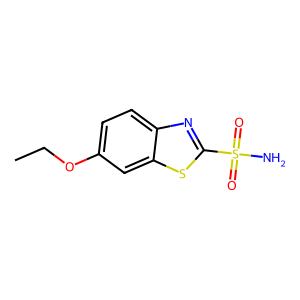

In [10]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

sample_smiles = df["smiles"].iloc[0]
print("SMILES string:", sample_smiles)

mol = Chem.MolFromSmiles(sample_smiles)

drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

SVG(svg)

## Step -2

In [18]:
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def smiles_to_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
print("Hello")

Hello


In [19]:
fingerprints = []
keep_rows = []

for i, smi in enumerate(df["smiles"]):
    fp = smiles_to_fingerprint(smi)
    if fp is not None:
        fingerprints.append(fp)
        keep_rows.append(i)

print("Total molecules processed:", len(df))
print("Successfully converted:", len(keep_rows))
print("Dropped (invalid SMILES):", len(df) - len(keep_rows))

Total molecules processed: 7831
Successfully converted: 7823
Dropped (invalid SMILES): 8


In [15]:
df_clean = df.iloc[keep_rows].reset_index(drop=True)
X = np.stack(fingerprints)

print("X shape:", X.shape)

X shape: (7823, 1024)


In [20]:
Y_raw = df_clean[TARGET_COLS].values.astype(np.float32)   # NaN আছে missing জায়গায়
mask = (~np.isnan(Y_raw)).astype(np.float32)                # 1 = label আছে, 0 = missing
Y = np.nan_to_num(Y_raw, nan=0.0)                            # NaN-কে placeholder 0 দিয়ে fill

print("Y shape:", Y.shape)
print("mask shape:", mask.shape)

Y shape: (7823, 12)
mask shape: (7823, 12)


In [21]:
for i, col in enumerate(TARGET_COLS):
    present_pct = mask[:, i].mean() * 100
    print(f"{col:15s}  data present: {present_pct:.1f}%")

NR-AR            data present: 92.8%
NR-AR-LBD        data present: 86.3%
NR-AhR           data present: 83.6%
NR-Aromatase     data present: 74.3%
NR-ER            data present: 79.1%
NR-ER-LBD        data present: 88.8%
NR-PPAR-gamma    data present: 82.4%
SR-ARE           data present: 74.5%
SR-ATAD5         data present: 90.3%
SR-HSE           data present: 82.6%
SR-MMP           data present: 74.2%
SR-p53           data present: 86.5%


## Step 3

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test, mask_train, mask_test = train_test_split(
    X, Y, mask, test_size=0.2, random_state=42
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 6258
Test set size: 1565


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

class Tox21Dataset(Dataset):
    def __init__(self, X, Y, mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.mask[idx]

In [25]:
train_dataset = Tox21Dataset(X_train, Y_train, mask_train)
test_dataset = Tox21Dataset(X_test, Y_test, mask_test)

print("Train dataset length:", len(train_dataset))
print("Test dataset length:", len(test_dataset))

Train dataset length: 6258
Test dataset length: 1565


In [26]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 98
Number of test batches: 25


In [27]:
sample_X, sample_Y, sample_mask = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)
print("Batch Y shape:", sample_Y.shape)
print("Batch mask shape:", sample_mask.shape)

Batch X shape: torch.Size([64, 1024])
Batch Y shape: torch.Size([64, 12])
Batch mask shape: torch.Size([64, 12])


## step 5

In [28]:
import torch.nn as nn

class MultiTaskToxModel(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=256, num_tasks=12):
        super().__init__()

        # SHARED layers: সব ১২টা টক্সিসিটি টাস্ক প্রথমে এই একই
        # layer-গুলোর মধ্য দিয়ে যায়। এখানেই model "এই molecule-টা
        # গঠনগতভাবে কেমন risky দেখতে" — এই general pattern শেখে।
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # HEADS: shared layer-এর পর, প্রতিটা টক্সিসিটি টাস্কের জন্য
        # আলাদা একটা ছোট linear layer (head) থাকে, যেটা shared
        # representation থেকে সেই নির্দিষ্ট টাস্কের toxicity score বের করে।
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, 1) for _ in range(num_tasks)
        ])

    def forward(self, x):
        shared_features = self.shared(x)
        # প্রতিটা head একই shared_features-এর উপর আলাদাভাবে চলে,
        # তারপর সব head-এর output একসাথে জোড়া লাগিয়ে (12,) বানানো হয়
        outputs = [head(shared_features) for head in self.heads]
        return torch.cat(outputs, dim=1)

In [29]:
model = MultiTaskToxModel(input_dim=X.shape[1], hidden_dim=256, num_tasks=12)
print(model)

MultiTaskToxModel(
  (shared): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (heads): ModuleList(
    (0-11): 12 x Linear(in_features=256, out_features=1, bias=True)
  )
)


In [30]:
def masked_bce_loss(logits, targets, mask):
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    raw_loss = loss_fn(logits, targets)      # প্রতিটা ঘরের জন্য আলাদা loss মান
    masked_loss = raw_loss * mask             # missing ঘরের loss-কে 0 বানিয়ে দিচ্ছে
    return masked_loss.sum() / mask.sum().clamp(min=1.0)

In [31]:
sample_X, sample_Y, sample_mask = next(iter(train_loader))

logits = model(sample_X)
loss = masked_bce_loss(logits, sample_Y, sample_mask)

print("Output logits shape:", logits.shape)
print("Sample loss value:", loss.item())

Output logits shape: torch.Size([64, 12])
Sample loss value: 0.6964188814163208


## step 6

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [33]:
EPOCHS = 30

train_losses = []

for epoch in range(EPOCHS):
    model.train()           # model-কে "training mode"-এ রাখে (Dropout সক্রিয় থাকে)
    total_loss = 0.0

    for X_batch, Y_batch, mask_batch in train_loader:
        optimizer.zero_grad()                          # আগের batch-এর gradient মুছে ফেলো
        logits = model(X_batch)                         # forward pass: prediction বের করো
        loss = masked_bce_loss(logits, Y_batch, mask_batch)  # ভুলের পরিমাণ মাপো
        loss.backward()                                 # backward pass: কে কতটুকু দায়ী বের করো
        optimizer.step()                                # weights সামান্য adjust করো

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  -  Train loss: {avg_loss:.4f}")

Epoch  1/30  -  Train loss: 0.3133
Epoch  2/30  -  Train loss: 0.2152
Epoch  3/30  -  Train loss: 0.1900
Epoch  4/30  -  Train loss: 0.1700
Epoch  5/30  -  Train loss: 0.1518
Epoch  6/30  -  Train loss: 0.1350
Epoch  7/30  -  Train loss: 0.1197
Epoch  8/30  -  Train loss: 0.1053
Epoch  9/30  -  Train loss: 0.0929
Epoch 10/30  -  Train loss: 0.0819
Epoch 11/30  -  Train loss: 0.0735
Epoch 12/30  -  Train loss: 0.0652
Epoch 13/30  -  Train loss: 0.0578
Epoch 14/30  -  Train loss: 0.0523
Epoch 15/30  -  Train loss: 0.0479
Epoch 16/30  -  Train loss: 0.0453
Epoch 17/30  -  Train loss: 0.0398
Epoch 18/30  -  Train loss: 0.0367
Epoch 19/30  -  Train loss: 0.0323
Epoch 20/30  -  Train loss: 0.0316
Epoch 21/30  -  Train loss: 0.0305
Epoch 22/30  -  Train loss: 0.0288
Epoch 23/30  -  Train loss: 0.0262
Epoch 24/30  -  Train loss: 0.0264
Epoch 25/30  -  Train loss: 0.0256
Epoch 26/30  -  Train loss: 0.0242
Epoch 27/30  -  Train loss: 0.0224
Epoch 28/30  -  Train loss: 0.0219
Epoch 29/30  -  Trai

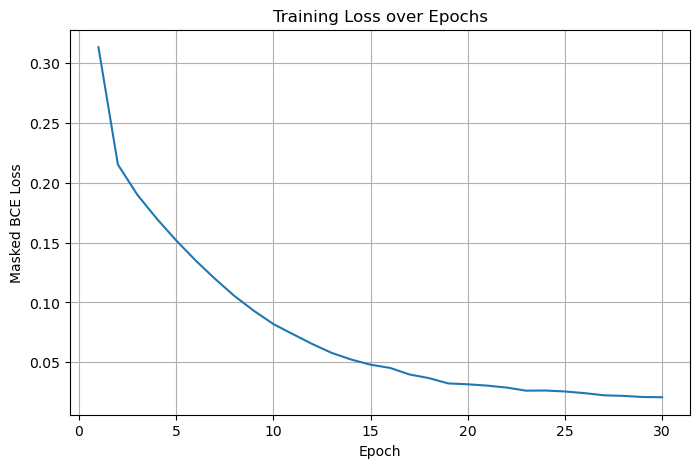

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Masked BCE Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

## Part-8

In [35]:
from sklearn.metrics import roc_auc_score

def evaluate_model(model, test_loader):
    model.eval()    # model-কে "evaluation mode"-এ রাখে (Dropout বন্ধ হয়ে যায়)
    all_probs, all_targets, all_masks = [], [], []

    with torch.no_grad():   # evaluation-এর সময় gradient হিসাব করার দরকার নেই
        for X_batch, Y_batch, mask_batch in test_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)   # logits-কে 0 থেকে 1 এর মধ্যে probability-তে রূপান্তর
            all_probs.append(probs)
            all_targets.append(Y_batch)
            all_masks.append(mask_batch)

    all_probs = torch.cat(all_probs).numpy()
    all_targets = torch.cat(all_targets).numpy()
    all_masks = torch.cat(all_masks).numpy()

    return all_probs, all_targets, all_masks

In [36]:
probs, targets, masks = evaluate_model(model, test_loader)

print("Predictions shape:", probs.shape)
print("Targets shape:", targets.shape)

Predictions shape: (1565, 12)
Targets shape: (1565, 12)


In [37]:
auc_scores = {}

for i, task in enumerate(TARGET_COLS):
    valid = masks[:, i] == 1   # শুধু সেইসব row নাও যেখানে আসল label ছিল

    if valid.sum() > 0 and len(np.unique(targets[valid, i])) > 1:
        auc = roc_auc_score(targets[valid, i], probs[valid, i])
        auc_scores[task] = auc
        print(f"{task:15s}  ROC-AUC = {auc:.3f}   (test samples used: {valid.sum()})")
    else:
        print(f"{task:15s}  স্কিপ করা হলো (যথেষ্ট label নেই)")

NR-AR            ROC-AUC = 0.745   (test samples used: 1441)
NR-AR-LBD        ROC-AUC = 0.871   (test samples used: 1334)
NR-AhR           ROC-AUC = 0.840   (test samples used: 1305)
NR-Aromatase     ROC-AUC = 0.795   (test samples used: 1161)
NR-ER            ROC-AUC = 0.706   (test samples used: 1229)
NR-ER-LBD        ROC-AUC = 0.809   (test samples used: 1376)
NR-PPAR-gamma    ROC-AUC = 0.803   (test samples used: 1268)
SR-ARE           ROC-AUC = 0.791   (test samples used: 1174)
SR-ATAD5         ROC-AUC = 0.768   (test samples used: 1406)
SR-HSE           ROC-AUC = 0.759   (test samples used: 1300)
SR-MMP           ROC-AUC = 0.844   (test samples used: 1138)
SR-p53           ROC-AUC = 0.832   (test samples used: 1357)


In [38]:
mean_auc = np.mean(list(auc_scores.values()))
print(f"\nMean ROC-AUC across {len(auc_scores)} tasks: {mean_auc:.3f}")


Mean ROC-AUC across 12 tasks: 0.797


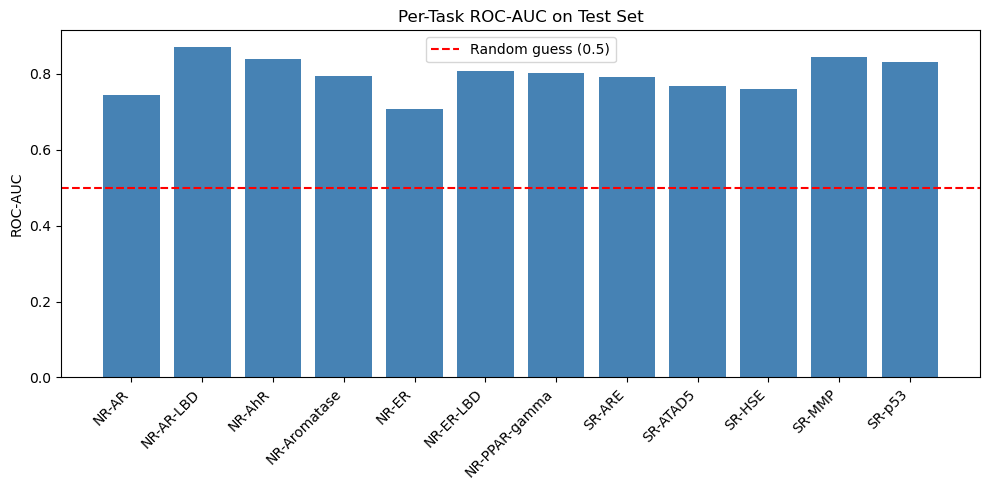

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(auc_scores.keys(), auc_scores.values(), color="steelblue")
plt.axhline(y=0.5, color="red", linestyle="--", label="Random guess (0.5)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Per-Task ROC-AUC on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

## part 9

In [40]:
torch.save(model.state_dict(), "tox21_model.pth")
print("Model saved as tox21_model.pth")

Model saved as tox21_model.pth


In [41]:
import json

config = {
    "n_bits": 1024,
    "radius": 2,
    "hidden_dim": 256,
    "target_cols": TARGET_COLS
}

with open("tox21_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config saved as tox21_config.json")

Config saved as tox21_config.json


In [42]:
import os
print("Files saved in:", os.getcwd())
print(os.listdir("."))

Files saved in: E:\Thesis_DrugToxicity
['.ipynb_checkpoints', 'clintox.csv', 'Test.ipynb', 'Thesis_test.ipynb', 'tox21.csv', 'tox21_config.json', 'tox21_model.pth']


In [43]:
loaded_model = MultiTaskToxModel(input_dim=1024, hidden_dim=256, num_tasks=12)
loaded_model.load_state_dict(torch.load("tox21_model.pth"))
loaded_model.eval()

print("Model loaded and ready to use, no retraining needed!")

Model loaded and ready to use, no retraining needed!


## part 10

In [44]:
def predict_toxicity(smiles_string, model, target_cols, n_bits=1024, radius=2):
    # Step A: SMILES কে valid molecule কিনা চেক করো
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        print("এই SMILES string-টা valid molecule হিসেবে পার্স করা যায়নি।")
        return None

    # Step B: SMILES কে সেই একই fingerprint-এ রূপান্তর করো (training-এর সময় যেভাবে করেছিলাম)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)

    # Step C: numpy array কে PyTorch tensor বানাও (batch dimension যোগ করতে হবে: shape (1, 1024))
    x_tensor = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)

    # Step D: model দিয়ে prediction করো
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).squeeze(0).numpy()   # shape (12,) probability

    # Step E: ফলাফল সুন্দরভাবে print করো
    print(f"SMILES: {smiles_string}\n")
    print(f"{'Toxicity Task':18s} {'Probability':>12s}   Prediction")
    print("-" * 50)
    for i, task in enumerate(target_cols):
        prob = probs[i]
        label = "TOXIC" if prob >= 0.5 else "Non-toxic"
        print(f"{task:18s} {prob:11.1%}   {label}")

    return probs

In [45]:
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
result = predict_toxicity(aspirin_smiles, model, TARGET_COLS)

SMILES: CC(=O)Oc1ccccc1C(=O)O

Toxicity Task       Probability   Prediction
--------------------------------------------------
NR-AR                     0.0%   Non-toxic
NR-AR-LBD                 0.0%   Non-toxic
NR-AhR                    0.0%   Non-toxic
NR-Aromatase              0.0%   Non-toxic
NR-ER                     0.2%   Non-toxic
NR-ER-LBD                 0.0%   Non-toxic
NR-PPAR-gamma             0.0%   Non-toxic
SR-ARE                    0.0%   Non-toxic
SR-ATAD5                  0.0%   Non-toxic
SR-HSE                    0.0%   Non-toxic
SR-MMP                    0.0%   Non-toxic
SR-p53                    0.0%   Non-toxic


In [48]:
your_smiles = "CC(=O)OC1=CC=CC=C1C(=O)[O-].[K+]"   # এখানে নিজের SMILES বসাও, এটা হলো শুধু Ethanol-এর উদাহরণ
result = predict_toxicity(your_smiles, model, TARGET_COLS)

SMILES: CC(=O)OC1=CC=CC=C1C(=O)[O-].[K+]

Toxicity Task       Probability   Prediction
--------------------------------------------------
NR-AR                     0.0%   Non-toxic
NR-AR-LBD                 0.0%   Non-toxic
NR-AhR                    0.0%   Non-toxic
NR-Aromatase              0.0%   Non-toxic
NR-ER                     0.2%   Non-toxic
NR-ER-LBD                 0.0%   Non-toxic
NR-PPAR-gamma             0.0%   Non-toxic
SR-ARE                    0.0%   Non-toxic
SR-ATAD5                  0.0%   Non-toxic
SR-HSE                    0.0%   Non-toxic
SR-MMP                    0.6%   Non-toxic
SR-p53                    0.0%   Non-toxic


### Hyper tuning

In [49]:
from sklearn.model_selection import train_test_split

# প্রথমে 80% train+val, 20% আলাদা করে রাখো (এটাই final test, একদম শেষে ব্যবহার হবে)
X_temp, X_test, Y_temp, Y_test, mask_temp, mask_test = train_test_split(
    X, Y, mask, test_size=0.2, random_state=42
)

# এখন বাকি 80% থেকে আবার ভাগ করো: 75% train, 25% validation (= মোটের 60%/20%)
X_train, X_val, Y_train, Y_val, mask_train, mask_val = train_test_split(
    X_temp, Y_temp, mask_temp, test_size=0.25, random_state=42
)

print("Train:", X_train.shape[0], " Validation:", X_val.shape[0], " Test:", X_test.shape[0])

Train: 4693  Validation: 1565  Test: 1565


In [51]:
train_dataset = Tox21Dataset(X_train, Y_train, mask_train)
val_dataset = Tox21Dataset(X_val, Y_val, mask_val)
test_dataset = Tox21Dataset(X_test, Y_test, mask_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [53]:
def train_and_evaluate(hidden_dim, lr, dropout, epochs, train_loader, eval_loader, verbose=False):
    # নতুন মডেল বানাও (dropout rate এবার parameter হিসেবে নিচ্ছি)
    class TunableModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.shared = nn.Sequential(
                nn.Linear(X.shape[1], hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(12)])

        def forward(self, x):
            shared_features = self.shared(x)
            outputs = [head(shared_features) for head in self.heads]
            return torch.cat(outputs, dim=1)

    model = TunableModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training
    for epoch in range(epochs):
        model.train()
        for X_batch, Y_batch, mask_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = masked_bce_loss(logits, Y_batch, mask_batch)
            loss.backward()
            optimizer.step()
        if verbose:
            print(f"  epoch {epoch+1}/{epochs} done")

    # Evaluation (validation বা test, যেটা দেওয়া হবে)
    probs, targets, masks = evaluate_model(model, eval_loader)
    aucs = []
    for i in range(12):
        valid = masks[:, i] == 1
        if valid.sum() > 0 and len(np.unique(targets[valid, i])) > 1:
            aucs.append(roc_auc_score(targets[valid, i], probs[valid, i]))

    return model, np.mean(aucs)

In [ ]:
import itertools

hidden_dims = [128, 256, 512]
learning_rates = [1e-3, 5e-4]
dropouts = [0.2, 0.3]

results = []

for hidden_dim, lr, dropout in itertools.product(hidden_dims, learning_rates, dropouts):
    print(f"Trying: hidden_dim={hidden_dim}, lr={lr}, dropout={dropout}")
    _, val_auc = train_and_evaluate(hidden_dim, lr, dropout, epochs=20,
                                      train_loader=train_loader, eval_loader=val_loader)
    print(f"  -> Validation Mean ROC-AUC: {val_auc:.3f}\n")
    results.append({"hidden_dim": hidden_dim, "lr": lr, "dropout": dropout, "val_auc": val_auc})

Trying: hidden_dim=128, lr=0.001, dropout=0.2
  -> Validation Mean ROC-AUC: 0.778

Trying: hidden_dim=128, lr=0.001, dropout=0.3
  -> Validation Mean ROC-AUC: 0.780

Trying: hidden_dim=128, lr=0.0005, dropout=0.2
  -> Validation Mean ROC-AUC: 0.785

Trying: hidden_dim=128, lr=0.0005, dropout=0.3


In [ ]:
results_df = pd.DataFrame(results).sort_values("val_auc", ascending=False)
results_df